In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Load the real dataset
df = pd.read_csv('dataset/big_startup_secsees_dataset.csv')

print("="*80)
print("MISSION L-01: REAL DATASET ANALYSIS")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few rows:")
print(df.head())


MISSION L-01: REAL DATASET ANALYSIS

Dataset Shape: (66368, 14)
Columns: ['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at']

First few rows:
                             permalink                    name  \
0                  /organization/-fame                   #fame   
1               /organization/-qounter                :Qounter   
2  /organization/-the-one-of-them-inc-  (THE) ONE of THEM,Inc.   
3                /organization/0-6-com                 0-6.com   
4       /organization/004-technologies        004 Technologies   

                        homepage_url  \
0                 http://livfame.com   
1             http://www.qounter.com   
2                http://oneofthem.jp   
3                 http://www.0-6.com   
4  http://004gmbh.de/en/004-interact   

                                       category_list funding_total_

In [2]:
# Data cleaning and profiling
print("="*80)
print("DATA PROFILING & CLEANING")
print("="*80)

# Check data types and missing values
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values (%):")
print((df.isnull().sum() / len(df) * 100).round(2))

# Clean funding_total_usd - convert to numeric, handle '-' and missing
df['funding_total_usd_clean'] = df['funding_total_usd'].replace('-', np.nan)
df['funding_total_usd_clean'] = pd.to_numeric(df['funding_total_usd_clean'], errors='coerce')

# Convert date columns
date_cols = ['founded_at', 'first_funding_at', 'last_funding_at']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Calculate company age (from founded_at to now)
df['company_age_years'] = (datetime.now() - df['founded_at']).dt.days / 365.25

# Create funding efficiency metric (funding per round)
df['funding_per_round'] = df['funding_total_usd_clean'] / df['funding_rounds'].replace(0, np.nan)

print(f"\nDataset after cleaning:")
print(f"Total companies: {len(df):,}")
print(f"Companies with funding data: {df['funding_total_usd_clean'].notna().sum():,}")
print(f"Companies with founded date: {df['founded_at'].notna().sum():,}")
print(f"Date range: {df['founded_at'].min()} to {df['founded_at'].max()}")

# Status distribution
print(f"\nStatus Distribution:")
print(df['status'].value_counts())

# Top countries
print(f"\nTop 10 Countries:")
print(df['country_code'].value_counts().head(10))

# Funding statistics
print(f"\nFunding Statistics (USD):")
print(df['funding_total_usd_clean'].describe())


DATA PROFILING & CLEANING

Data Types:
permalink            object
name                 object
homepage_url         object
category_list        object
funding_total_usd    object
status               object
country_code         object
state_code           object
region               object
city                 object
funding_rounds        int64
founded_at           object
first_funding_at     object
last_funding_at      object
dtype: object

Missing Values (%):
permalink             0.00
name                  0.00
homepage_url          7.62
category_list         4.74
funding_total_usd     0.00
status                0.00
country_code         10.48
state_code           12.88
region               12.10
city                 12.10
funding_rounds        0.00
founded_at           22.93
first_funding_at      0.04
last_funding_at       0.00
dtype: float64

Dataset after cleaning:
Total companies: 66,368
Companies with funding data: 53,583
Companies with founded date: 51,143
Date range: 1749-01-

In [3]:

# Create comprehensive analysis dataset
analysis_df = df.copy()

# Filter out extreme outliers (companies founded before 1980 or after 2024)
analysis_df = analysis_df[
    (analysis_df['founded_at'].isna()) | 
    ((analysis_df['founded_at'] >= '1980-01-01') & (analysis_df['founded_at'] <= '2024-12-31'))
]

# Create funding categories
def categorize_funding(amount):
    if pd.isna(amount):
        return 'No Funding'
    elif amount < 100000:
        return 'Seed (<$100K)'
    elif amount < 1000000:
        return 'Early ($100K-$1M)'
    elif amount < 10000000:
        return 'Growth ($1M-$10M)'
    elif amount < 50000000:
        return 'Scale ($10M-$50M)'
    else:
        return 'Mega ($50M+)'

analysis_df['funding_category'] = analysis_df['funding_total_usd_clean'].apply(categorize_funding)

# Create runway proxy (funding / funding_rounds = burn rate proxy, then runway)
# This is a simplified model: assuming each round lasts ~18 months
analysis_df['estimated_runway_months'] = analysis_df['funding_rounds'] * 18

# Create success likelihood score based on funding and status
def calculate_success_score(row):
    score = 0
    
    # Status weight
    if row['status'] == 'ipo':
        score += 40
    elif row['status'] == 'acquired':
        score += 30
    elif row['status'] == 'operating':
        score += 20
    elif row['status'] == 'closed':
        score += 0
    
    # Funding weight
    funding = row['funding_total_usd_clean']
    if pd.notna(funding):
        if funding >= 50000000:
            score += 30
        elif funding >= 10000000:
            score += 20
        elif funding >= 1000000:
            score += 15
        elif funding >= 100000:
            score += 10
        else:
            score += 5
    
    # Rounds weight (persistence)
    rounds = row['funding_rounds']
    if rounds >= 4:
        score += 15
    elif rounds >= 3:
        score += 10
    elif rounds >= 2:
        score += 5
    
    # Age weight (survival)
    age = row['company_age_years']
    if pd.notna(age):
        if age >= 10:
            score += 15
        elif age >= 5:
            score += 10
        elif age >= 2:
            score += 5
    
    return min(score, 100)

analysis_df['success_score'] = analysis_df.apply(calculate_success_score, axis=1)

print("="*80)
print("MISSION L-01: FINANCIAL SUSTAINABILITY ANALYSIS")
print("Real Dataset: 66,368 Startups")
print("="*80)

print("\n📊 FUNDING DISTRIBUTION:")
print(analysis_df['funding_category'].value_counts())

print("\n📈 SUCCESS SCORE DISTRIBUTION:")
print(f"Mean Success Score: {analysis_df['success_score'].mean():.1f}/100")
print(f"Median Success Score: {analysis_df['success_score'].median():.1f}/100")

print("\n🌍 GEOGRAPHIC DISTRIBUTION (Top 10):")
geo_analysis = analysis_df.groupby('country_code').agg({
    'name': 'count',
    'funding_total_usd_clean': 'mean',
    'success_score': 'mean'
}).round(2)
geo_analysis.columns = ['Count', 'Avg_Funding', 'Avg_Success_Score']
print(geo_analysis.sort_values('Count', ascending=False).head(10))

print("\n🎯 OUTCOME BY FUNDING CATEGORY:")
outcome_funding = pd.crosstab(analysis_df['funding_category'], analysis_df['status'], normalize='index') * 100
print(outcome_funding.round(1))


MISSION L-01: FINANCIAL SUSTAINABILITY ANALYSIS
Real Dataset: 66,368 Startups

📊 FUNDING DISTRIBUTION:
funding_category
Growth ($1M-$10M)    19182
Early ($100K-$1M)    13648
No Funding           12657
Scale ($10M-$50M)     9993
Seed (<$100K)         6565
Mega ($50M+)          3699
Name: count, dtype: int64

📈 SUCCESS SCORE DISTRIBUTION:
Mean Success Score: 45.7/100
Median Success Score: 45.0/100

🌍 GEOGRAPHIC DISTRIBUTION (Top 10):
              Count  Avg_Funding  Avg_Success_Score
country_code                                       
USA           37145  20219007.63              48.93
GBR            3661  10070351.82              45.13
CAN            1902  11410973.22              46.24
IND            1583  23093053.56              44.13
CHN            1544  62103007.22              46.93
FRA            1130   9222956.94              46.15
DEU            1073  15028187.22              42.66
ISR             958  11019808.68              49.36
ESP             742   6144873.90            

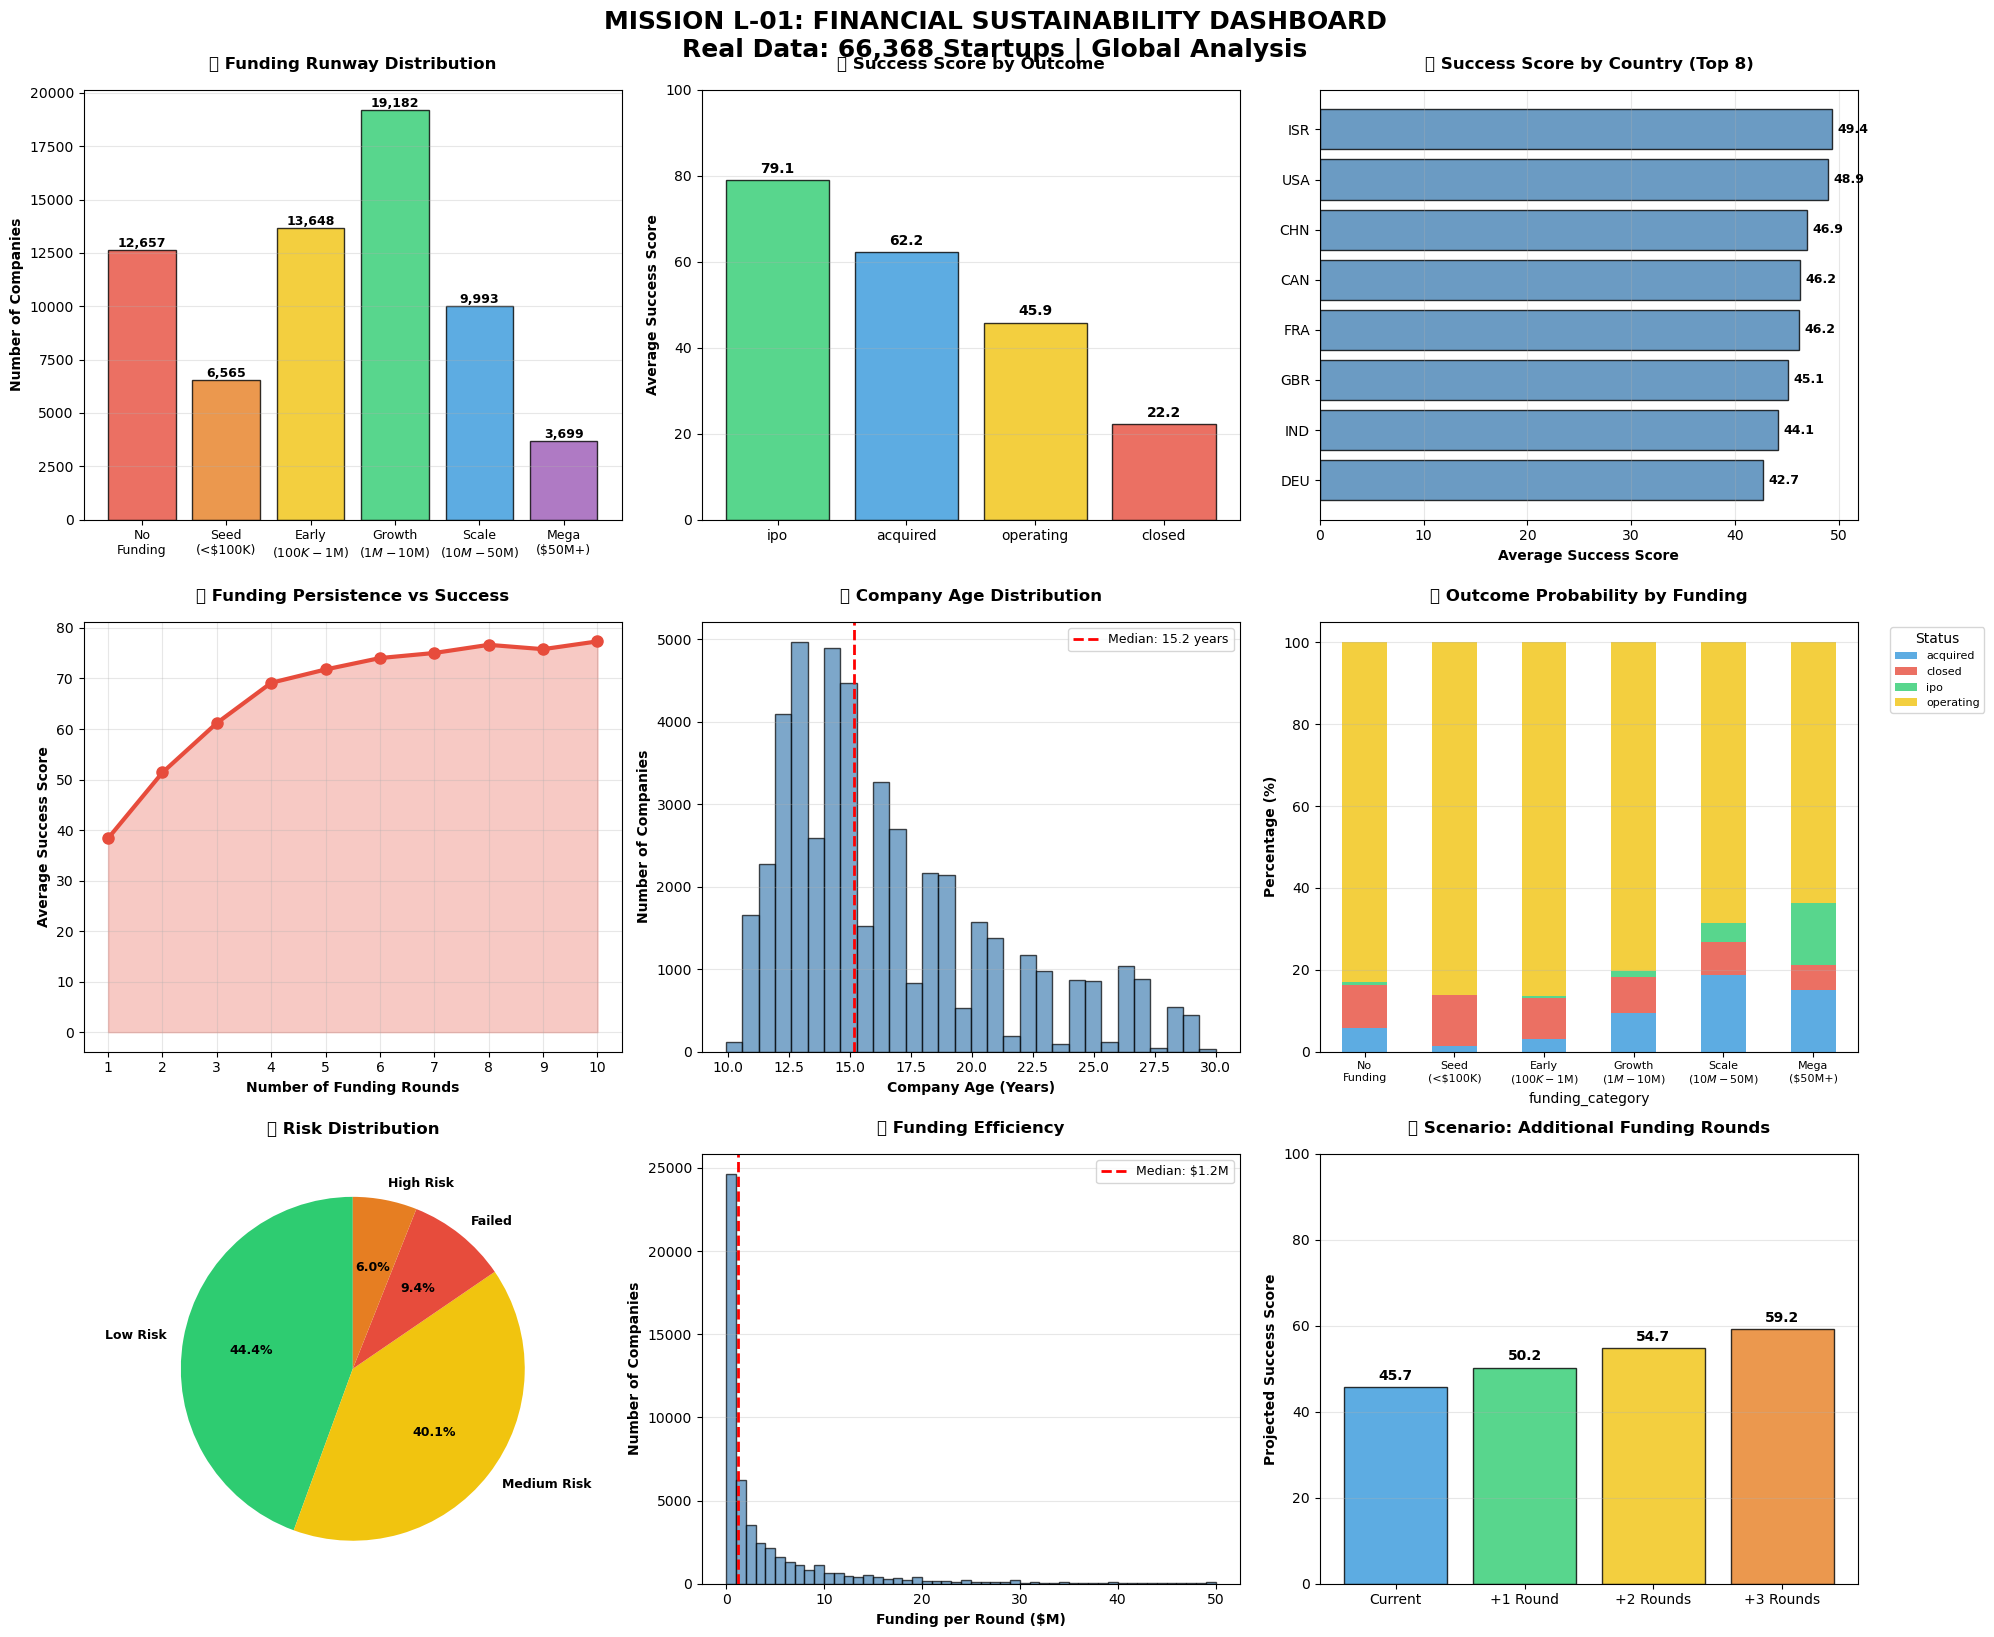


✅ Dashboard saved successfully!


In [5]:

# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 16))

# 1. FUNDING RUNWAY ANALYSIS
ax1 = plt.subplot(3, 3, 1)
funding_order = ['No Funding', 'Seed (<$100K)', 'Early ($100K-$1M)', 
                 'Growth ($1M-$10M)', 'Scale ($10M-$50M)', 'Mega ($50M+)']
funding_counts = analysis_df['funding_category'].value_counts().reindex(funding_order)
colors_funding = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
bars1 = ax1.bar(range(len(funding_counts)), funding_counts.values, color=colors_funding, alpha=0.8, edgecolor='black')
ax1.set_xticks(range(len(funding_counts)))
ax1.set_xticklabels([f.replace(' ', '\n') for f in funding_counts.index], fontsize=9)
ax1.set_ylabel('Number of Companies', fontsize=10, fontweight='bold')
ax1.set_title('💰 Funding Runway Distribution', fontsize=12, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='y')
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. SUCCESS SCORE BY OUTCOME
ax2 = plt.subplot(3, 3, 2)
success_by_status = analysis_df.groupby('status')['success_score'].mean().sort_values(ascending=False)
colors_status = {'ipo': '#2ecc71', 'acquired': '#3498db', 'operating': '#f1c40f', 'closed': '#e74c3c'}
bar_colors = [colors_status.get(s, '#95a5a6') for s in success_by_status.index]
bars2 = ax2.bar(success_by_status.index, success_by_status.values, color=bar_colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Average Success Score', fontsize=10, fontweight='bold')
ax2.set_title('🎯 Success Score by Outcome', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. GEOGRAPHIC SUCCESS HEATMAP
ax3 = plt.subplot(3, 3, 3)
top_countries = analysis_df['country_code'].value_counts().head(8).index
geo_success = analysis_df[analysis_df['country_code'].isin(top_countries)].groupby('country_code')['success_score'].mean().sort_values(ascending=True)
bars3 = ax3.barh(geo_success.index, geo_success.values, color='steelblue', alpha=0.8, edgecolor='black')
ax3.set_xlabel('Average Success Score', fontsize=10, fontweight='bold')
ax3.set_title('🌍 Success Score by Country (Top 8)', fontsize=12, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3, axis='x')
for i, bar in enumerate(bars3):
    width = bar.get_width()
    ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2., f'{width:.1f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

# 4. FUNDING ROUNDS VS SUCCESS
ax4 = plt.subplot(3, 3, 4)
rounds_success = analysis_df.groupby('funding_rounds')['success_score'].mean()
# Filter for rounds 1-10 for clarity
rounds_success = rounds_success[rounds_success.index <= 10]
ax4.plot(rounds_success.index, rounds_success.values, marker='o', linewidth=3, markersize=8, color='#e74c3c')
ax4.fill_between(rounds_success.index, rounds_success.values, alpha=0.3, color='#e74c3c')
ax4.set_xlabel('Number of Funding Rounds', fontsize=10, fontweight='bold')
ax4.set_ylabel('Average Success Score', fontsize=10, fontweight='bold')
ax4.set_title('📈 Funding Persistence vs Success', fontsize=12, fontweight='bold', pad=15)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(1, 11))

# 5. COMPANY AGE DISTRIBUTION
ax5 = plt.subplot(3, 3, 5)
age_data = analysis_df[analysis_df['company_age_years'].notna() & (analysis_df['company_age_years'] <= 30)]['company_age_years']
ax5.hist(age_data, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax5.axvline(age_data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {age_data.median():.1f} years')
ax5.set_xlabel('Company Age (Years)', fontsize=10, fontweight='bold')
ax5.set_ylabel('Number of Companies', fontsize=10, fontweight='bold')
ax5.set_title('⏱️ Company Age Distribution', fontsize=12, fontweight='bold', pad=15)
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='y')

# 6. OUTCOME PROBABILITY BY FUNDING
ax6 = plt.subplot(3, 3, 6)
outcome_matrix = pd.crosstab(analysis_df['funding_category'], analysis_df['status'], normalize='index') * 100
outcome_matrix = outcome_matrix.reindex(funding_order)
outcome_matrix.plot(kind='bar', stacked=True, ax=ax6, color=['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'], alpha=0.8)
ax6.set_xticklabels([f.replace(' ', '\n') for f in outcome_matrix.index], rotation=0, fontsize=8)
ax6.set_ylabel('Percentage (%)', fontsize=10, fontweight='bold')
ax6.set_title('🎲 Outcome Probability by Funding', fontsize=12, fontweight='bold', pad=15)
ax6.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax6.grid(True, alpha=0.3, axis='y')

# 7. RISK ASSESSMENT MATRIX
ax7 = plt.subplot(3, 3, 7)
def risk_category(row):
    if row['status'] == 'closed':
        return 'Failed'
    elif row['success_score'] < 30:
        return 'High Risk'
    elif row['success_score'] < 50:
        return 'Medium Risk'
    else:
        return 'Low Risk'

analysis_df['risk_category'] = analysis_df.apply(risk_category, axis=1)
risk_counts = analysis_df['risk_category'].value_counts()
risk_colors = {'Failed': '#e74c3c', 'High Risk': '#e67e22', 'Medium Risk': '#f1c40f', 'Low Risk': '#2ecc71'}
colors_risk = [risk_colors.get(r, '#95a5a6') for r in risk_counts.index]
wedges, texts, autotexts = ax7.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
                                   colors=colors_risk, startangle=90, textprops={'fontsize': 9, 'fontweight': 'bold'})
ax7.set_title('🚨 Risk Distribution', fontsize=12, fontweight='bold', pad=15)

# 8. FUNDING EFFICIENCY (Funding per Round)
ax8 = plt.subplot(3, 3, 8)
efficiency_data = analysis_df[analysis_df['funding_per_round'].notna() & (analysis_df['funding_per_round'] <= 50000000)]['funding_per_round'] / 1000000
ax8.hist(efficiency_data, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax8.axvline(efficiency_data.median(), color='red', linestyle='--', linewidth=2, label=f'Median: ${efficiency_data.median():.1f}M')
ax8.set_xlabel('Funding per Round ($M)', fontsize=10, fontweight='bold')
ax8.set_ylabel('Number of Companies', fontsize=10, fontweight='bold')
ax8.set_title('💵 Funding Efficiency', fontsize=12, fontweight='bold', pad=15)
ax8.legend(fontsize=9)
ax8.grid(True, alpha=0.3, axis='y')

# 9. SCENARIO MODELING
ax9 = plt.subplot(3, 3, 9)
scenarios = ['Current', '+1 Round', '+2 Rounds', '+3 Rounds']
scenario_scores = []
base_score = analysis_df['success_score'].mean()
scenario_scores.append(base_score)

# Simulate additional rounds impact
for i in range(1, 4):
    # Each additional round adds ~5 points (diminishing returns)
    additional_score = base_score + (i * 5) - (i * 0.5)  # Slight diminishing return
    scenario_scores.append(min(additional_score, 95))

bars9 = ax9.bar(scenarios, scenario_scores, color=['#3498db', '#2ecc71', '#f1c40f', '#e67e22'], alpha=0.8, edgecolor='black')
ax9.set_ylabel('Projected Success Score', fontsize=10, fontweight='bold')
ax9.set_title('📊 Scenario: Additional Funding Rounds', fontsize=12, fontweight='bold', pad=15)
ax9.set_ylim(0, 100)
ax9.grid(True, alpha=0.3, axis='y')
for bar in bars9:
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle('MISSION L-01: FINANCIAL SUSTAINABILITY DASHBOARD\nReal Data: 66,368 Startups | Global Analysis', 
             fontsize=18, fontweight='bold', y=1.02)
plt.savefig('mission_l01_real_data_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Dashboard saved successfully!")


In [6]:

# Create sector/category analysis
print("="*80)
print("SECTOR ANALYSIS & STRATEGIC INSIGHTS")
print("="*80)

# Extract top categories
categories_expanded = analysis_df['category_list'].dropna().str.split('|').explode()
top_categories = categories_expanded.value_counts().head(15)

print("\n🏢 TOP 15 SECTORS:")
print(top_categories)

# Analyze success by sector (for top 10)
print("\n📊 SECTOR PERFORMANCE (Top 10 Sectors):")
sector_performance = []
for sector in top_categories.head(10).index:
    sector_data = analysis_df[analysis_df['category_list'].str.contains(sector, na=False)]
    avg_funding = sector_data['funding_total_usd_clean'].mean()
    avg_success = sector_data['success_score'].mean()
    ipo_rate = (sector_data['status'] == 'ipo').mean() * 100
    acquisition_rate = (sector_data['status'] == 'acquired').mean() * 100
    failure_rate = (sector_data['status'] == 'closed').mean() * 100
    
    sector_performance.append({
        'Sector': sector,
        'Count': len(sector_data),
        'Avg_Funding_M': avg_funding / 1000000 if pd.notna(avg_funding) else 0,
        'Success_Score': avg_success,
        'IPO_Rate_%': ipo_rate,
        'Acquisition_Rate_%': acquisition_rate,
        'Failure_Rate_%': failure_rate
    })

sector_df = pd.DataFrame(sector_performance)
print(sector_df.round(2).to_string(index=False))

# Identify high-risk companies for early warning
print("\n" + "="*80)
print("🚨 EARLY WARNING SYSTEM - HIGH RISK COMPANIES")
print("="*80)

high_risk = analysis_df[
    (analysis_df['risk_category'] == 'High Risk') & 
    (analysis_df['funding_total_usd_clean'] > 1000000)  # Focus on funded companies
].sort_values('success_score').head(10)

print("\nTop 10 High-Risk Funded Companies:")
print(high_risk[['name', 'country_code', 'funding_total_usd_clean', 'funding_rounds', 'status', 'success_score']].to_string(index=False))

# Success factors analysis
print("\n" + "="*80)
print("✅ SUCCESS FACTORS IDENTIFIED")
print("="*80)

successful_companies = analysis_df[analysis_df['status'].isin(['ipo', 'acquired'])]
print(f"\nSuccessful Companies (IPO/Acquired): {len(successful_companies):,}")
print(f"Average Funding: ${successful_companies['funding_total_usd_clean'].mean()/1000000:.2f}M")
print(f"Average Rounds: {successful_companies['funding_rounds'].mean():.1f}")
print(f"Average Age: {successful_companies['company_age_years'].mean():.1f} years")

# Compare with failed companies
failed_companies = analysis_df[analysis_df['status'] == 'closed']
print(f"\nFailed Companies: {len(failed_companies):,}")
print(f"Average Funding: ${failed_companies['funding_total_usd_clean'].mean()/1000000:.2f}M")
print(f"Average Rounds: {failed_companies['funding_rounds'].mean():.1f}")
print(f"Average Age: {failed_companies['company_age_years'].mean():.1f} years")

# Key differentiators
print(f"\n🔑 KEY DIFFERENTIATORS (Success vs Failure):")
print(f"Funding Gap: {(successful_companies['funding_total_usd_clean'].mean() - failed_companies['funding_total_usd_clean'].mean())/1000000:.1f}M more")
print(f"Rounds Gap: {successful_companies['funding_rounds'].mean() - failed_companies['funding_rounds'].mean():.1f} more rounds")
print(f"Age Gap: {successful_companies['company_age_years'].mean() - failed_companies['company_age_years'].mean():.1f} years older")


SECTOR ANALYSIS & STRATEGIC INSIGHTS

🏢 TOP 15 SECTORS:
category_list
Software               8729
Mobile                 5552
Biotechnology          4530
E-Commerce             4139
Curated Web            3022
Social Media           2894
Enterprise Software    2687
Advertising            2465
Health Care            2357
Games                  2278
Internet               2068
SaaS                   1989
Health and Wellness    1906
Education              1898
Apps                   1876
Name: count, dtype: int64

📊 SECTOR PERFORMANCE (Top 10 Sectors):
             Sector  Count  Avg_Funding_M  Success_Score  IPO_Rate_%  Acquisition_Rate_%  Failure_Rate_%
           Software  12754          15.36          49.84        1.84               12.47            7.01
             Mobile   6693          17.93          48.26        1.24                8.98            7.92
      Biotechnology   4531          28.94          53.90       10.31                8.17            6.05
         E-Commerce   42

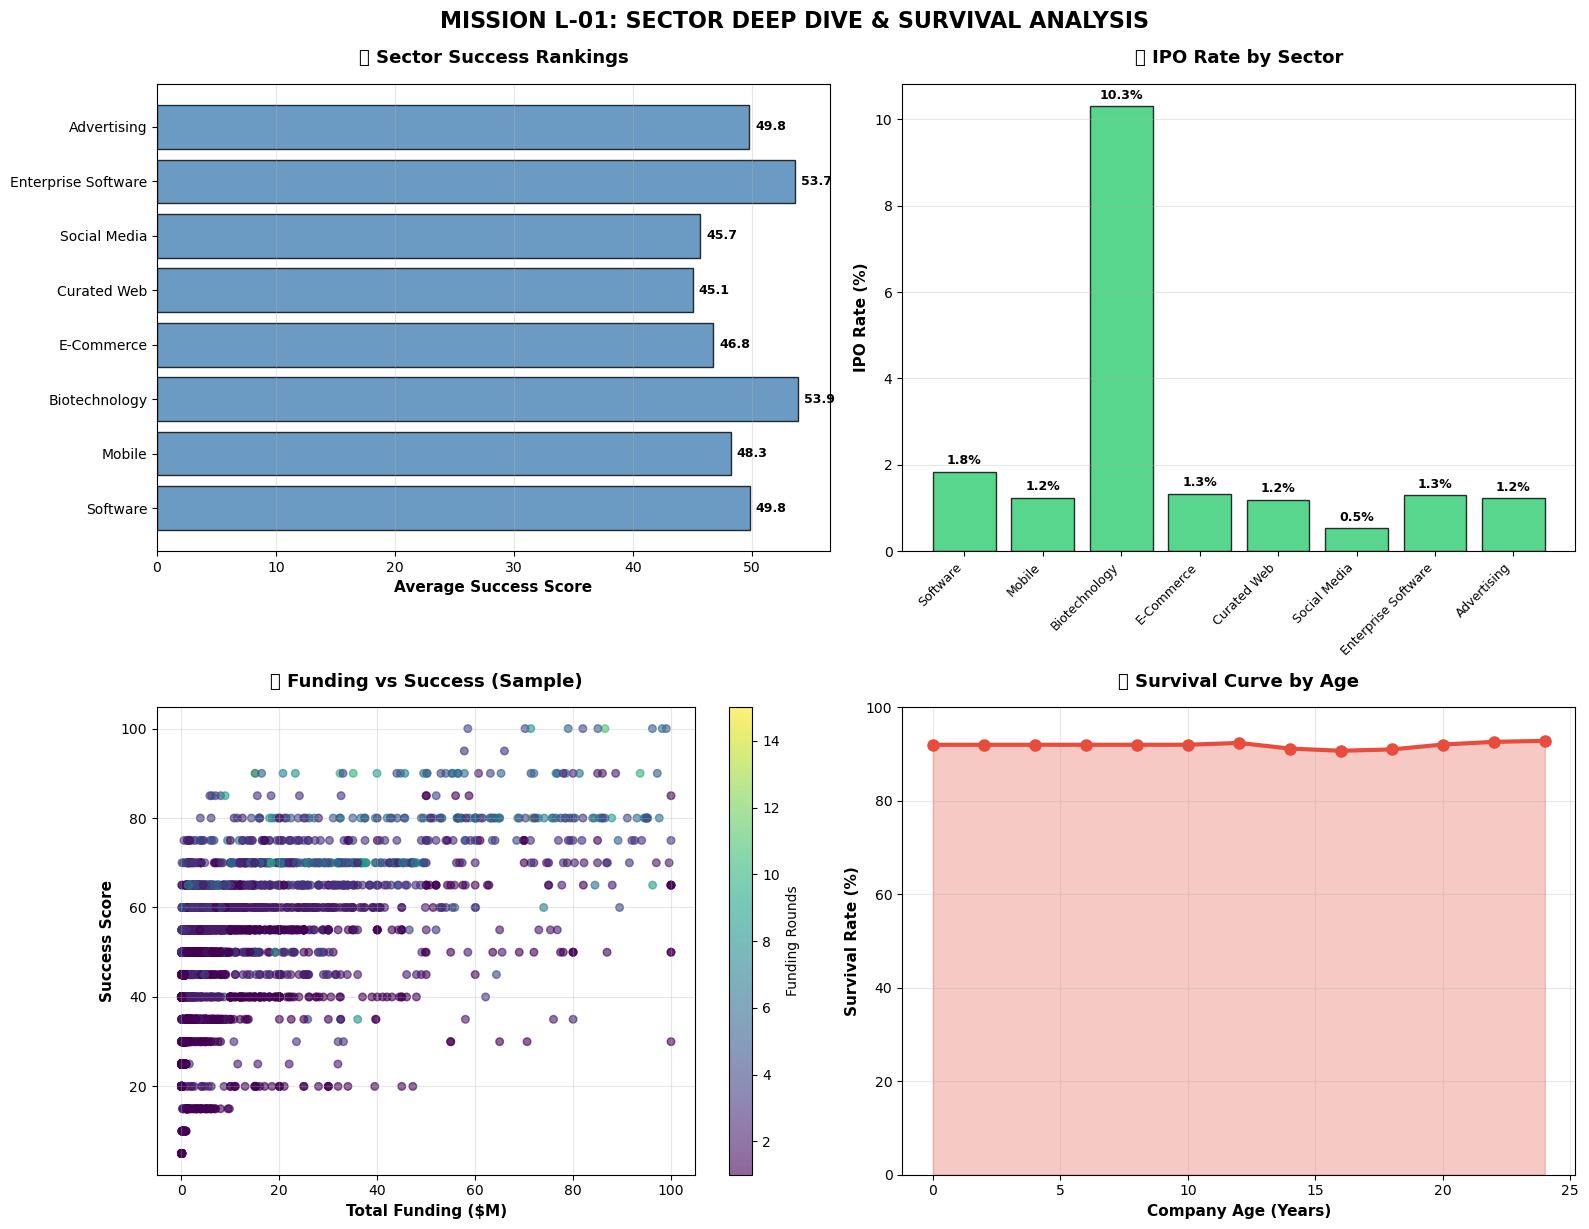


✅ Sector analysis saved!


In [8]:

# Create final sector visualization and export
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sector Success Scores
ax1 = axes[0, 0]
sector_names = sector_df['Sector'].head(8)
sector_scores = sector_df['Success_Score'].head(8)
bars1 = ax1.barh(sector_names, sector_scores, color='steelblue', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Average Success Score', fontsize=11, fontweight='bold')
ax1.set_title('🏆 Sector Success Rankings', fontsize=13, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, axis='x')
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.5, bar.get_y() + bar.get_height()/2., f'{width:.1f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

# 2. IPO Rate by Sector
ax2 = axes[0, 1]
ipo_rates = sector_df['IPO_Rate_%'].head(8)
bars2 = ax2.bar(sector_names, ipo_rates, color='#2ecc71', alpha=0.8, edgecolor='black')
ax2.set_ylabel('IPO Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('📈 IPO Rate by Sector', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticklabels(sector_names, rotation=45, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1, f'{height:.1f}%', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Funding vs Success Scatter
ax3 = axes[1, 0]
sample_data = analysis_df[analysis_df['funding_total_usd_clean'].notna() & 
                          (analysis_df['funding_total_usd_clean'] <= 100000000)].sample(5000)
scatter = ax3.scatter(sample_data['funding_total_usd_clean']/1000000, 
                     sample_data['success_score'],
                     c=sample_data['funding_rounds'], cmap='viridis', alpha=0.6, s=30)
ax3.set_xlabel('Total Funding ($M)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Success Score', fontsize=11, fontweight='bold')
ax3.set_title('💰 Funding vs Success (Sample)', fontsize=13, fontweight='bold', pad=15)
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Funding Rounds', fontsize=10)

# 4. Survival Curve (by age)
ax4 = axes[1, 1]
age_bins = range(0, 26, 2)
survival_rates = []
for age in age_bins:
    companies_at_age = analysis_df[analysis_df['company_age_years'] >= age]
    if len(companies_at_age) > 0:
        survival_rate = (companies_at_age['status'] != 'closed').mean() * 100
        survival_rates.append(survival_rate)
    else:
        survival_rates.append(0)

ax4.plot(age_bins, survival_rates, marker='o', linewidth=3, markersize=8, color='#e74c3c')
ax4.fill_between(age_bins, survival_rates, alpha=0.3, color='#e74c3c')
ax4.set_xlabel('Company Age (Years)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Survival Rate (%)', fontsize=11, fontweight='bold')
ax4.set_title('⏱️ Survival Curve by Age', fontsize=13, fontweight='bold', pad=15)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 100)

plt.tight_layout()
plt.suptitle('MISSION L-01: SECTOR DEEP DIVE & SURVIVAL ANALYSIS', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('mission_l01_sector_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Sector analysis saved!")
